In [72]:
import time
import importlib

# 01: Reading the open-source datasets

This section contains code to read the open-source datasets, considered in the paper: "Estimation of reactive power loads for low voltage network consumers using smart meter data", by Ewout Venstermans, Md. Umar Hashmi, and Marta Vanin.

Three datasets are available via the `dataset_chosen` key:

| key | description |
|---|---|
|`Slovakia`| Slovakian dataset with 1000 buildings measured in 2016|
|`Germany`| German dataset with 38 buildings measured from 2018 till 2020|
|`USA`| MFRED (USA) dataset with 26 buildings measured from 2019 till 2021|


> **Note:** Due to the size of the Slovakian dataset, loading/clustering this data takes 1h 16min to load. Hence, it is recommended to start the reproduction of the results with the German or MFRED dataset


## 1.1: Selecting the dataset

In [73]:
dataset_chosen = "USA"

## 1.2 Loading the data

In [94]:
import data_cleaning_functions as dcf
from pathlib import Path

if dataset_chosen == "Slovakia":
    path_folder = Path("data/repository/Slovakia")
    original_data_train, active_power_train, reactive_power_train, active_power_original_train, reactive_power_original_train, houses_train, houses_PV_train, original_data_test, active_power_test, reactive_power_test, active_power_original_test, reactive_power_original_test, houses_test, houses_PV_test, meter_data, first_key, last_key, first_key_test, last_key_test = dcf.Slovakia_data_loading(path_folder)
    
    train_data_merged = dcf.Merge_data_Slovak(active_power_train, reactive_power_train)
    train_data_merged_original = dcf.Merge_data_Slovak(active_power_original_train, reactive_power_original_train)
    test_data_merged = dcf.Merge_data_Slovak(active_power_test, reactive_power_test)
    test_data_merged_original = dcf.Merge_data_Slovak(active_power_original_test, reactive_power_original_test)

elif dataset_chosen == "Germany":
    path_folder = Path("data/repository/Germany")
    original_data_train, original_data_test, houses_train, houses_test, first_key, last_key = dcf.Germany_data_loading(path_folder)
elif dataset_chosen == "USA":
    path_folder = Path("data/repository/USA")
    original_data_train, original_data_test, first_key, last_key = dcf.USA_data_loading(path_folder)
else:
    raise ValueError("Invalid dataset chosen. Please choose from 'Slovakia', 'Germany', or 'USA'.")

35040


## 1.3 Outlier removal



In [96]:
import outlier_removal as orem
importlib.reload(orem)

if dataset_chosen == "Slovakia":
    data_train_updated, upper_bound_active_train, lower_bound_active_train, upper_bound_reactive_train, lower_bound_reactive_train, outliers_P_dict_train, outliers_Q_dict_train = orem.outlier_removal(train_data_merged, train_data_merged_original, dataset_chosen)
    data_test_updated, upper_bound_active_test, lower_bound_active_test, upper_bound_reactive_test, lower_bound_reactive_test, outliers_P_dict_test, outliers_Q_dict_test = orem.outlier_removal(test_data_merged, test_data_merged_original, dataset_chosen)

    active_power_train_updated = {i: data_train_updated[i]['P'] for i in data_train_updated.keys()}
    reactive_power_train_updated = {i: data_train_updated[i]['Q'] for i in data_train_updated.keys()}
    active_power_test_updated = {i: data_test_updated[i]['P'] for i in data_test_updated.keys()}
    reactive_power_test_updated = {i: data_test_updated[i]['Q'] for i in data_test_updated.keys()}

elif dataset_chosen == "Germany":
    data_train_updated, upper_bound_active_train, lower_bound_active_train, upper_bound_reactive_train, lower_bound_reactive_train, outliers_P_dict_train, outliers_Q_dict_train = orem.outlier_removal(original_data_train, original_data_train, dataset_chosen)
    data_test_updated, upper_bound_active_test, lower_bound_active_test, upper_bound_reactive_test, lower_bound_reactive_test, outliers_P_dict_test, outliers_Q_dict_test = orem.outlier_removal(original_data_test, original_data_test, dataset_chosen)
elif dataset_chosen == "USA":
    data_train_updated, upper_bound_active_train, lower_bound_active_train, upper_bound_reactive_train, lower_bound_reactive_train, outliers_P_dict_train, outliers_Q_dict_train = orem.outlier_removal(original_data_train, original_data_train, dataset_chosen)
    data_test_updated, upper_bound_active_test, lower_bound_active_test, upper_bound_reactive_test, lower_bound_reactive_test, outliers_P_dict_test, outliers_Q_dict_test = orem.outlier_removal(original_data_test, original_data_test, dataset_chosen)


Shows a comparison between the original data and the data after outliers are removed for a specific building.

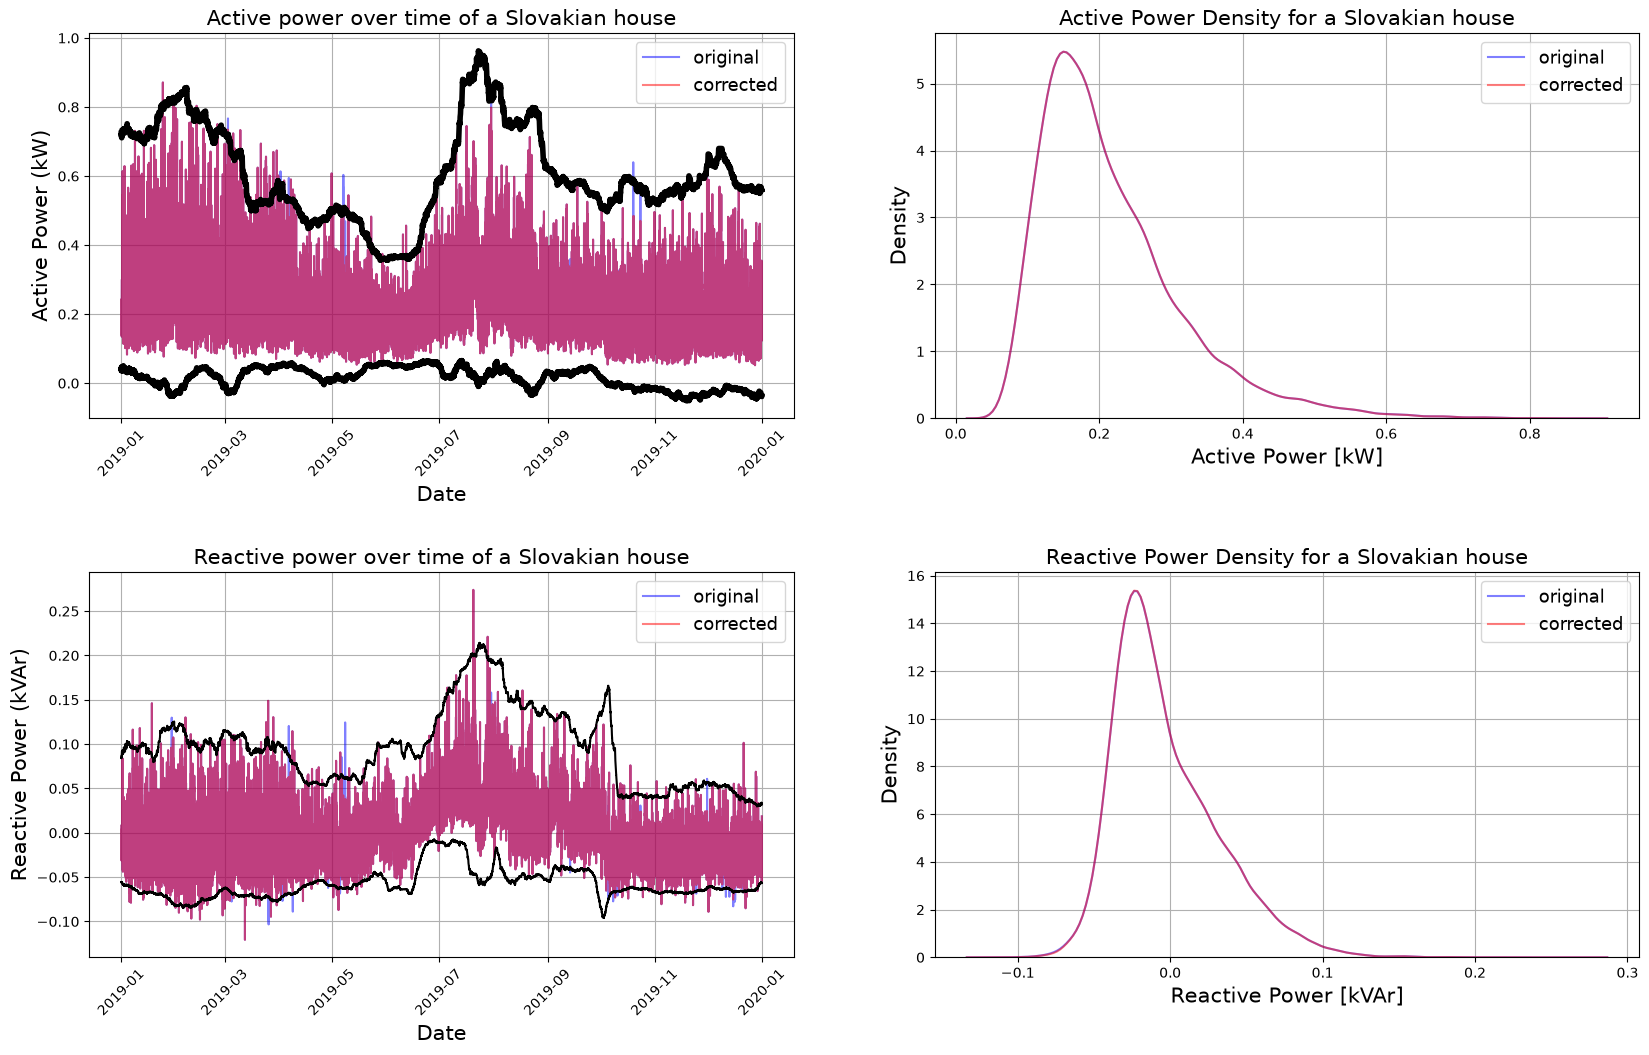

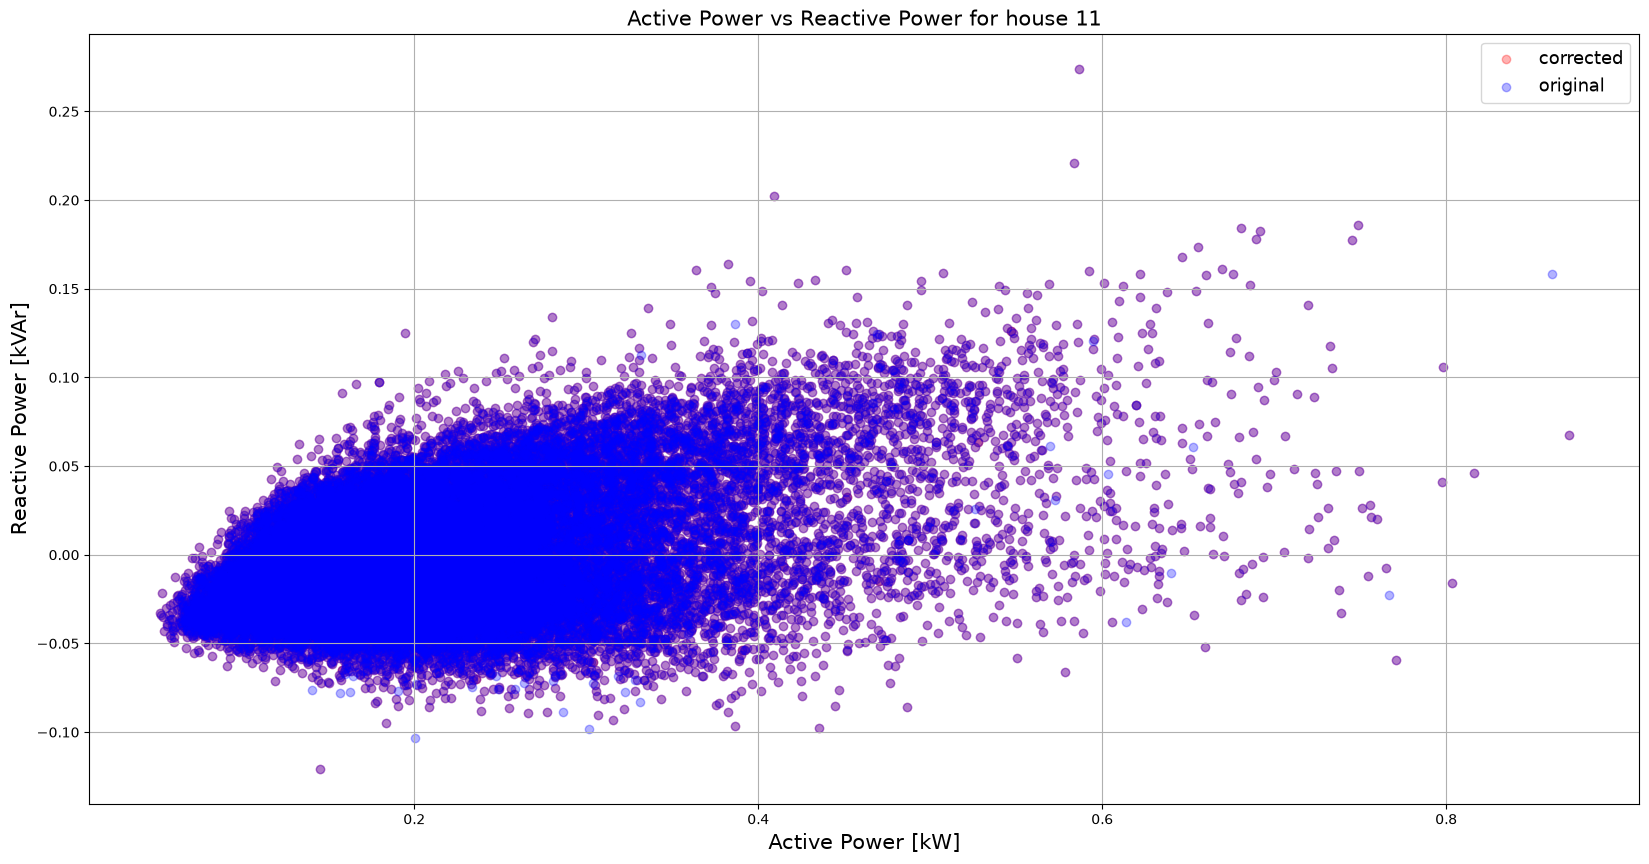

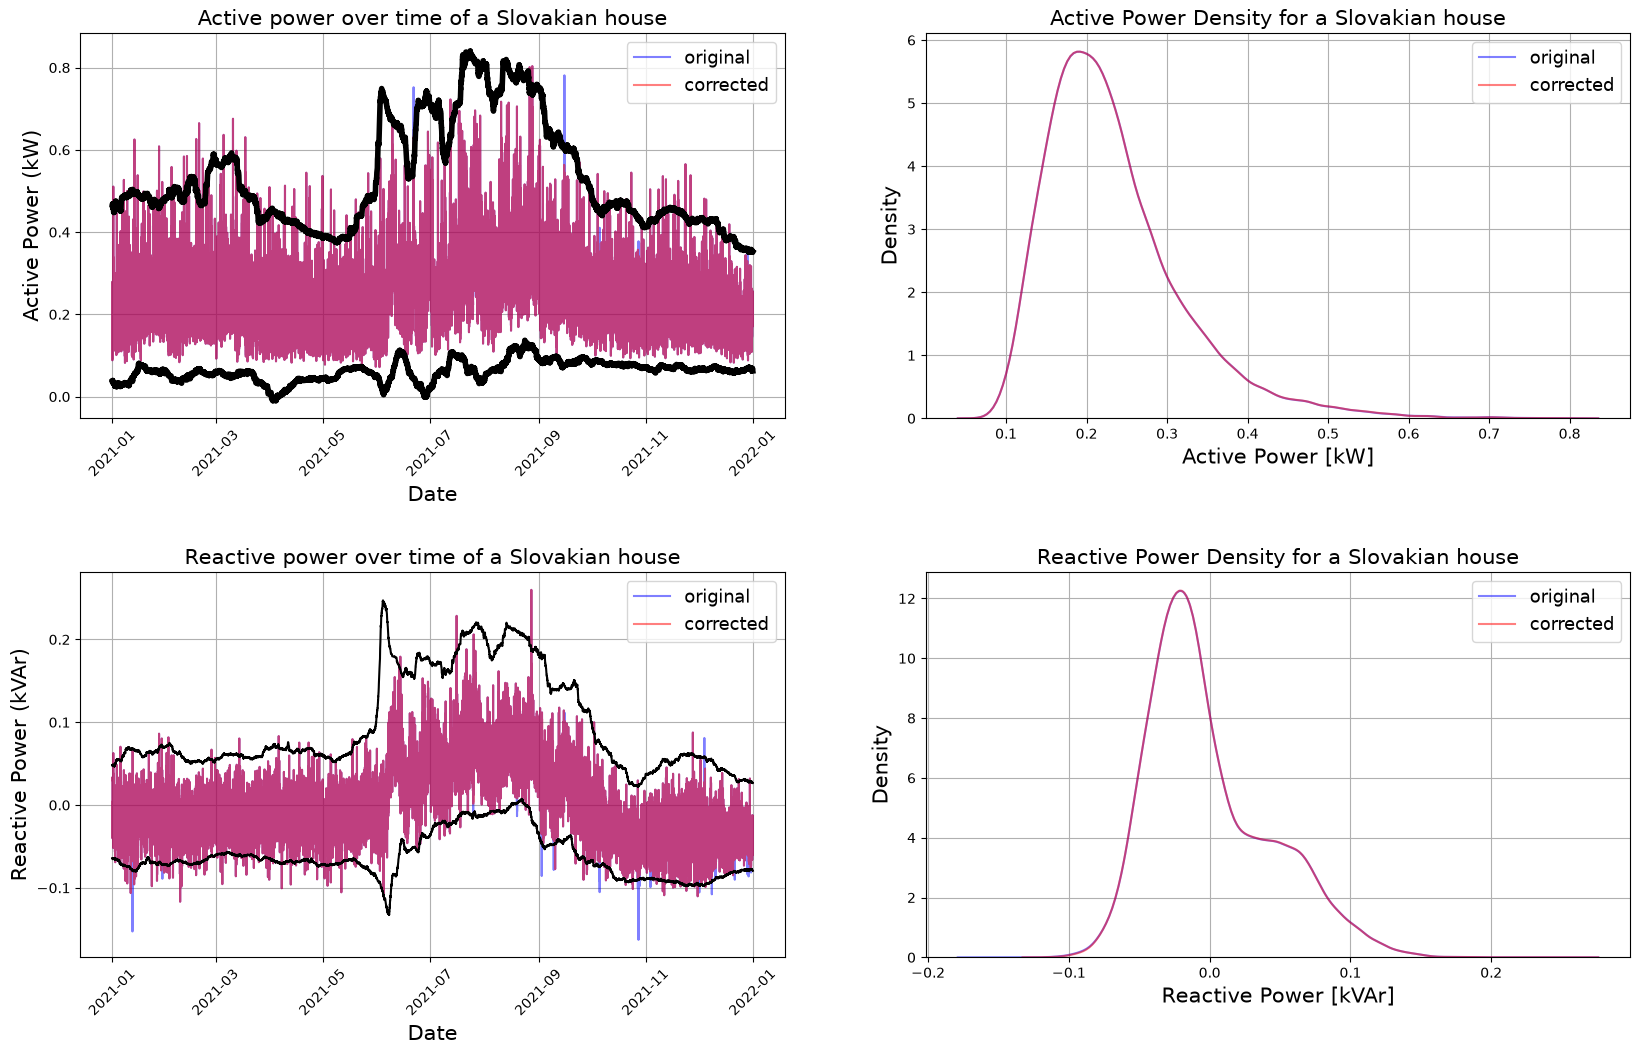

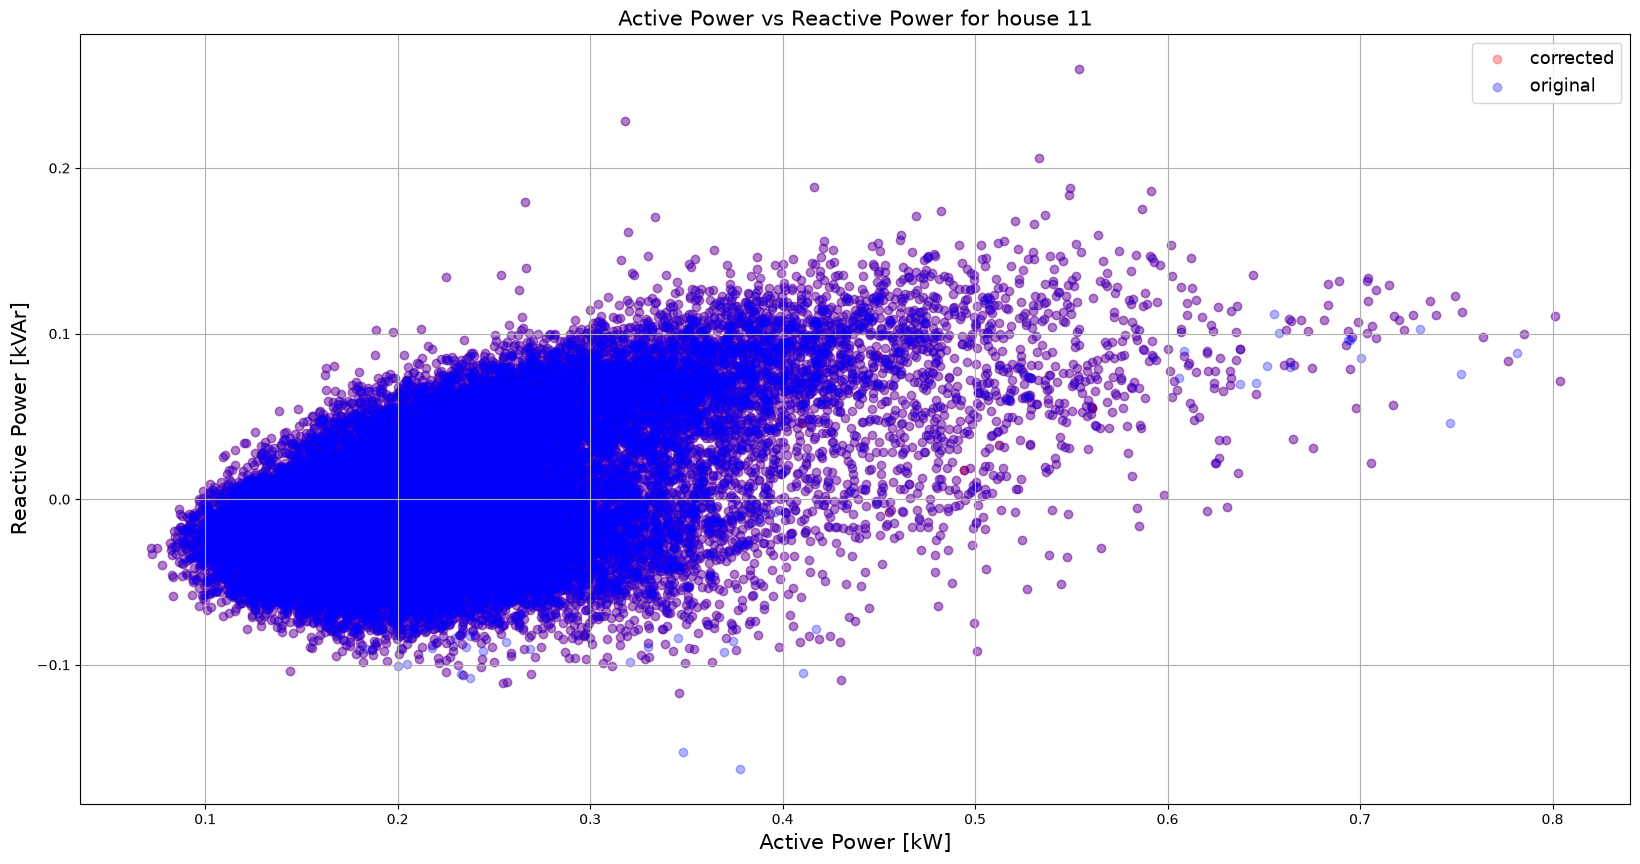

In [65]:
house = 11

if dataset_chosen == "Slovakia":
    if house in original_data_train.keys():
        merged_data_train_updated = dcf.Merge_data_Slovak(active_power_train_updated, reactive_power_train_updated)
        orem.outlier_plots(merged_data_train_updated, train_data_merged_original, lower_bound_active_train, upper_bound_active_train, lower_bound_reactive_train, upper_bound_reactive_train, house)
    elif house in original_data_test.keys():
        merged_data_test_updated = dcf.Merge_data_Slovak(active_power_test_updated, reactive_power_test_updated)
        orem.outlier_plots(merged_data_test_updated, test_data_merged_original, lower_bound_active_test, upper_bound_active_test, lower_bound_reactive_test, upper_bound_reactive_test, house)
    else:
        print(f"House {house} not found in the dataset.")
elif dataset_chosen == "Germany":
    if house in original_data_train.keys():
        orem.outlier_plots(data_train_updated, original_data_train, lower_bound_active_train, upper_bound_active_train, lower_bound_reactive_train, upper_bound_reactive_train, house)
    if house in original_data_test.keys():
        orem.outlier_plots(data_test_updated, original_data_test, lower_bound_active_test, upper_bound_active_test, lower_bound_reactive_test, upper_bound_reactive_test, house)
    if house not in original_data_train.keys() and house not in original_data_test.keys():
        print(f"House {house} not found in the dataset.")
elif dataset_chosen == "USA":
    if house in original_data_train.keys():
        orem.outlier_plots(data_train_updated, original_data_train, lower_bound_active_train, upper_bound_active_train, lower_bound_reactive_train, upper_bound_reactive_train, house)
    if house in original_data_test.keys():
        orem.outlier_plots(data_test_updated, original_data_test, lower_bound_active_test, upper_bound_active_test, lower_bound_reactive_test, upper_bound_reactive_test, house)
    if house not in original_data_train.keys() and house not in original_data_test.keys():
        print(f"House {house} not found in the dataset.")

## 1.4 Adding metadata and final cleaning of the dataset

These blocks add the final metadata into the train and test set, as well as update the PF (power factor) and S (apparent power) behavior before executing a final check and cleaning of the dataset, when required.

In [97]:
if dataset_chosen == "Slovakia":
    data_train = dcf.merge_data_Slovak(original_data_train, active_power_train_updated, reactive_power_train_updated, meter_data, houses_train, houses_PV_train)
    data_test = dcf.merge_data_Slovak(original_data_test, active_power_test_updated, reactive_power_test_updated, meter_data, houses_test, houses_PV_test)
elif dataset_chosen == "Germany":
    data_train = dcf.merge_data_German(data_train_updated)
    data_test = dcf.merge_data_German(data_test_updated)
elif dataset_chosen == "USA":
    data_train = dcf.merge_data_USA(data_train_updated)
    data_test = dcf.merge_data_USA(data_test_updated)

In [98]:
if dataset_chosen == "Slovakia":
    first_index_train = list(data_train.keys())[0]
    first_index_test = list(data_test.keys())[0]
    power_dict_train, houses_train = dcf.cleaning(data_train, data_train[first_index_train])
    power_dict_test, houses_test = dcf.cleaning(data_test, data_test[first_index_test])
    print(power_dict_train[1].head())
if dataset_chosen == "Germany":
    first_index_train = list(data_train.keys())[0]
    first_index_test = list(data_test.keys())[0]
    power_dict_train, houses_train = dcf.cleaning(data_train, data_train[first_index_train])
    power_dict_test, houses_test = dcf.cleaning(data_test, data_test[first_index_test])
    print(power_dict_train[1].head())
if dataset_chosen == "USA":
    first_index_train = list(data_train.keys())[0]
    first_index_test = list(data_test.keys())[0]
    power_dict_train, houses_train = dcf.cleaning(data_train, data_train[first_index_train])
    power_dict_test, houses_test = dcf.cleaning(data_test, data_test[first_index_test])
    print(power_dict_train[1].head())


                           Nr       P       Q         S        PF PV
DateTimeUTC                                                         
2019-01-01 00:00:00-05:00   1  0.0893  0.0365  0.096471  0.925662  0
2019-01-01 00:15:00-05:00   1  0.0993  0.0609  0.116487  0.852453  0
2019-01-01 00:30:00-05:00   1  0.0972  0.0572  0.112782  0.861843  0
2019-01-01 00:45:00-05:00   1  0.0810  0.0120  0.081884  0.989203  0
2019-01-01 01:00:00-05:00   1  0.0711  0.0268  0.075983  0.935733  0


## 1.5 Storing the cleaned data

In [99]:
if dataset_chosen =="Slovakia":
    path_folder = Path("data/repository/Slovakia")
    dcf.storing(power_dict_train, path_folder, "power_dict_train")
    time.sleep(10)
    dcf.storing(power_dict_test, path_folder, "power_dict_test")
elif dataset_chosen =="Germany":
    path_folder = Path("data/repository/Germany")
    dcf.storing(power_dict_train, path_folder, "power_dict_train")
    time.sleep(10)
    dcf.storing(power_dict_test, path_folder, "power_dict_test")
elif dataset_chosen =="USA":
    path_folder = Path("data/repository/USA")
    dcf.storing(power_dict_train, path_folder, "power_dict_train")
    time.sleep(10)
    dcf.storing(power_dict_test, path_folder, "power_dict_test")

# 02: Visualizing the cleaned data

Visualizes the power factor (PF) for all buildings (key = `all`) and for each building (key = `building_key`) seperately.

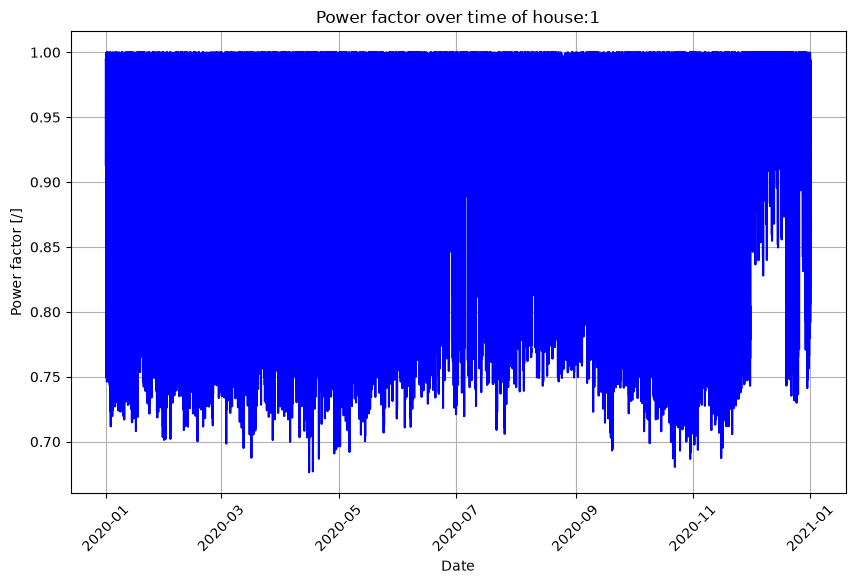

In [53]:
import visualization_cleaned_data as vis
key = 1
if key == 'all':
        vis.PF_plots(power_dict_train)
        vis.PF_plots(power_dict_test)
elif key in power_dict_train.keys():
        vis.PF_plots_individual(power_dict_train, key)
elif key in power_dict_test.keys():
        vis.PF_plots_individual(power_dict_test, key)


Visualizes the active (P) and reactive power (Q) for all buildings (key = `all`) and for each building (key = `building`) seperately.

In [14]:
key = 1
if key == 'all':
    vis.P_full_year(power_dict_train)
    vis.P_full_year(power_dict_test)
    vis.Q_full_year(power_dict_train)
    vis.Q_full_year(power_dict_test)
elif key in power_dict_train.keys():
    vis.P_full_year_individual(power_dict_train, key)
    vis.Q_full_year_individual(power_dict_train, key)
elif key in power_dict_test.keys():
    vis.P_full_year_individual(power_dict_test, key)
    vis.Q_full_year_individual(power_dict_test, key)

DatetimeIndex(['2016-01-01 00:00:00+00:00', '2016-01-01 00:15:00+00:00',
               '2016-01-01 00:30:00+00:00', '2016-01-01 00:45:00+00:00',
               '2016-01-01 01:00:00+00:00', '2016-01-01 01:15:00+00:00',
               '2016-01-01 01:30:00+00:00', '2016-01-01 01:45:00+00:00',
               '2016-01-01 02:00:00+00:00', '2016-01-01 02:15:00+00:00',
               ...
               '2017-01-29 21:45:00+00:00', '2017-01-29 22:00:00+00:00',
               '2017-01-29 22:15:00+00:00', '2017-01-29 22:30:00+00:00',
               '2017-01-29 22:45:00+00:00', '2017-01-29 23:00:00+00:00',
               '2017-01-29 23:15:00+00:00', '2017-01-29 23:30:00+00:00',
               '2017-01-29 23:45:00+00:00', '2017-01-30 00:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='datetime', length=37921, freq=None)


Visualizes the reactive power (Q) and power factor (PF) over the active power (P)

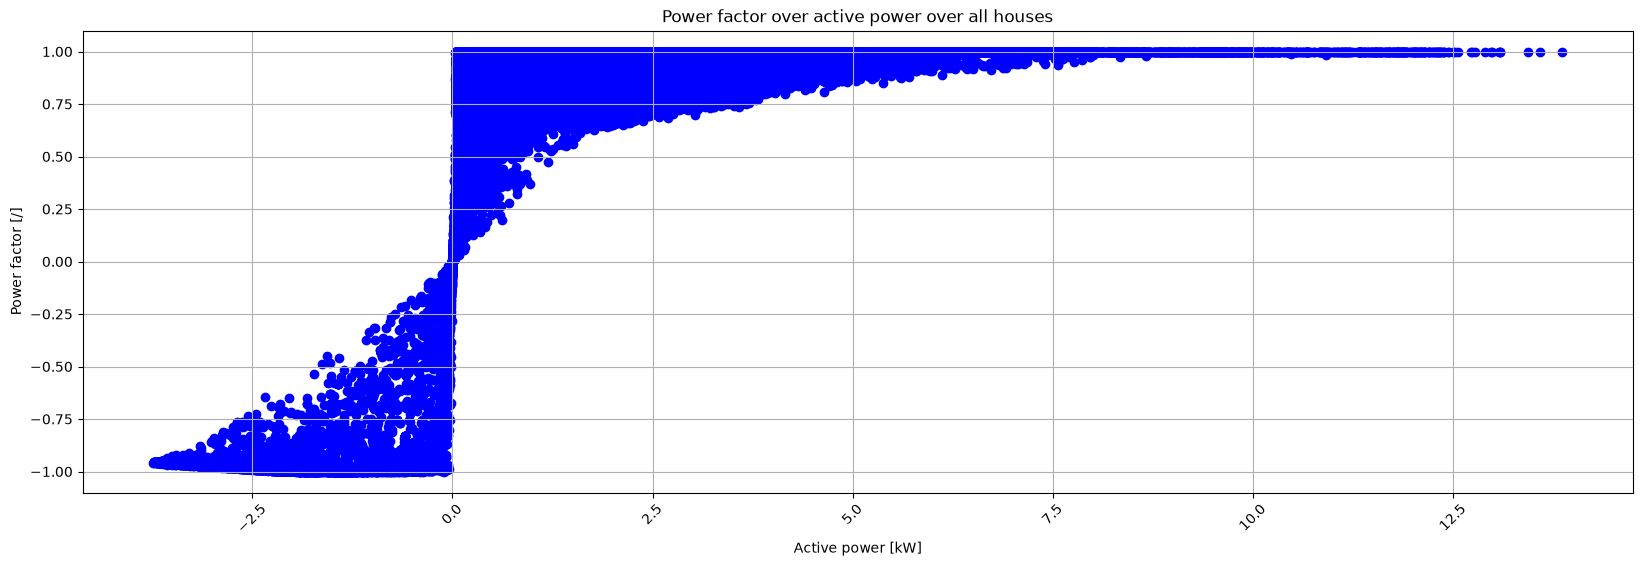

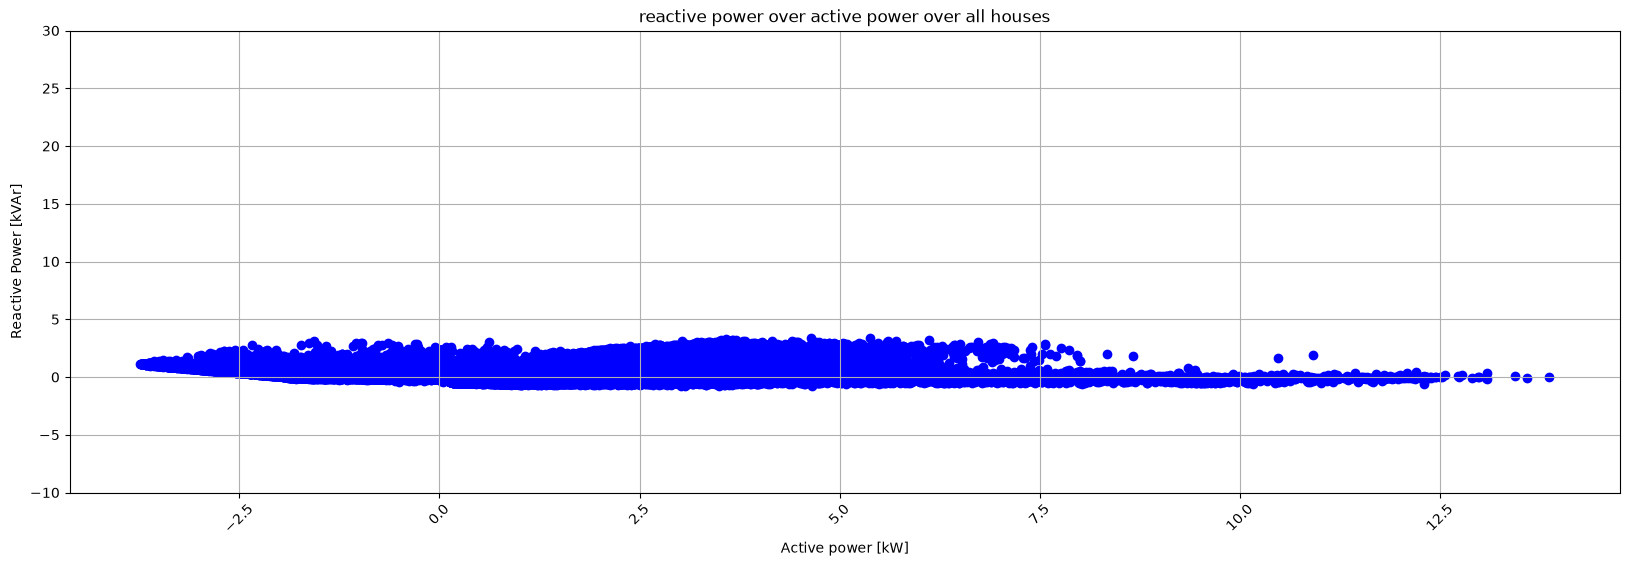

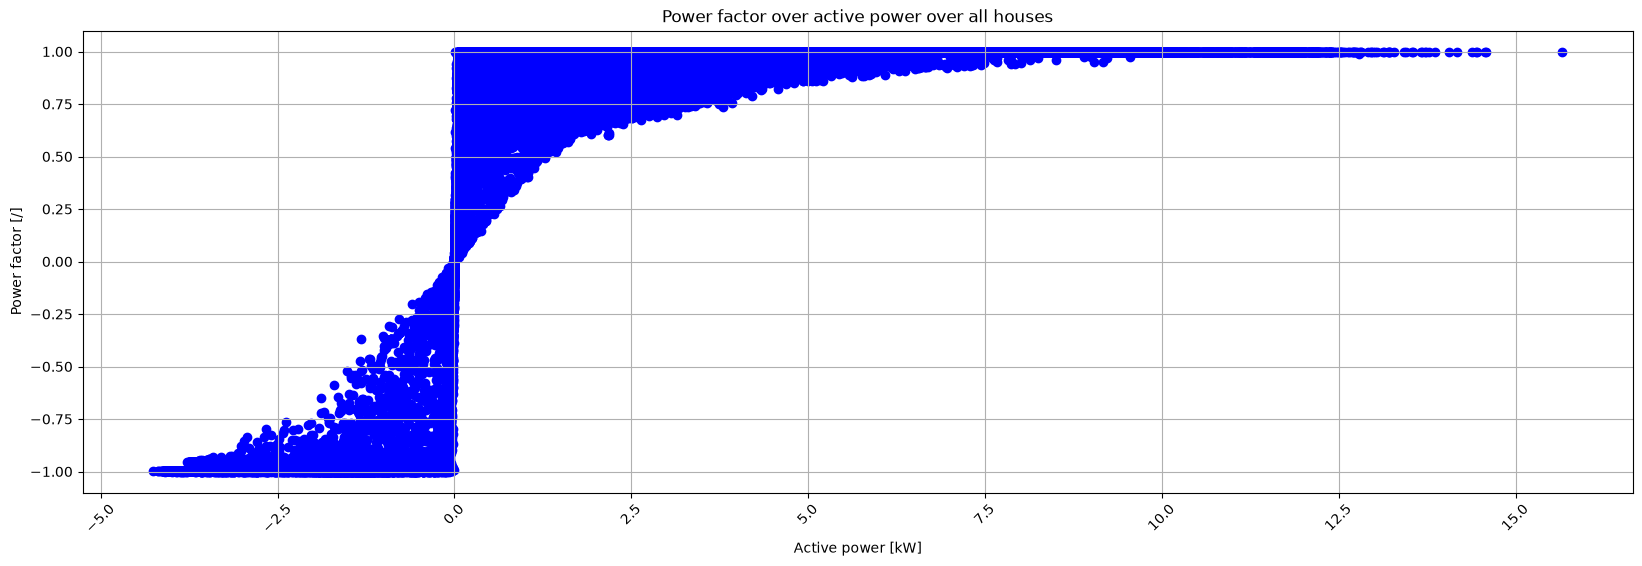

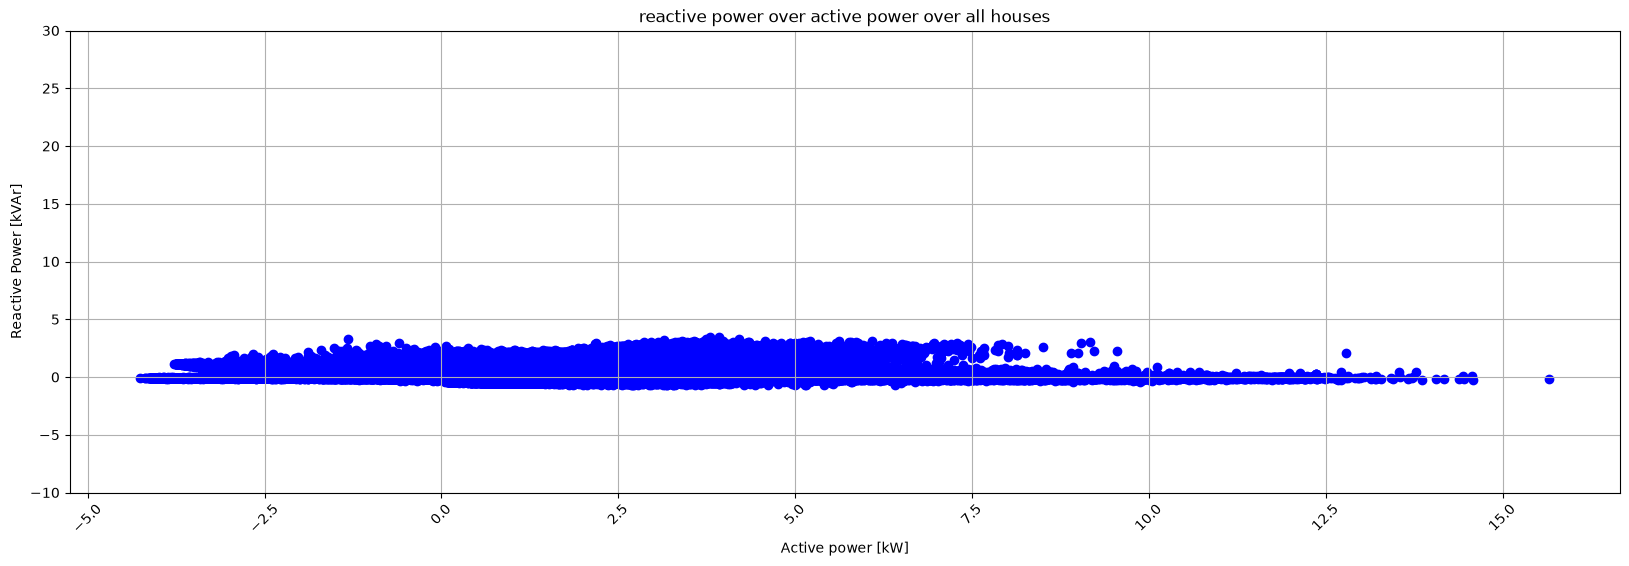

In [54]:
vis.PF_Q_over_P(power_dict_train)
vis.PF_Q_over_P(power_dict_test)

Visualizes the density plots of annual energy and peak power for all functions

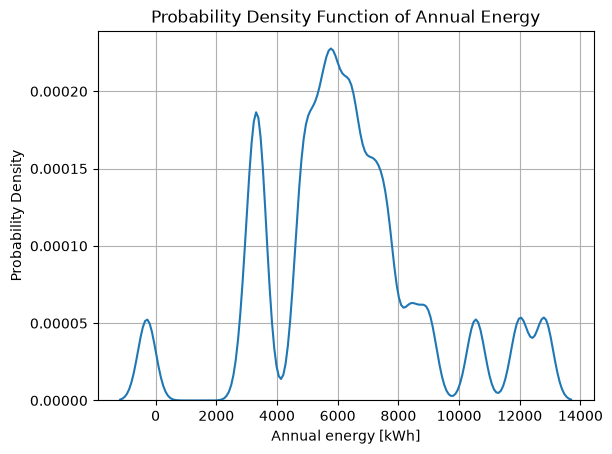

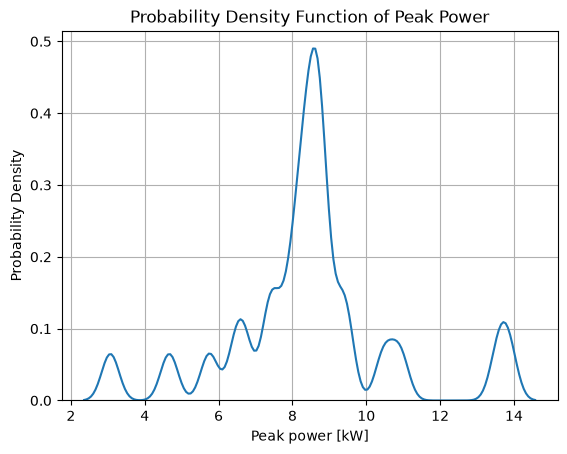

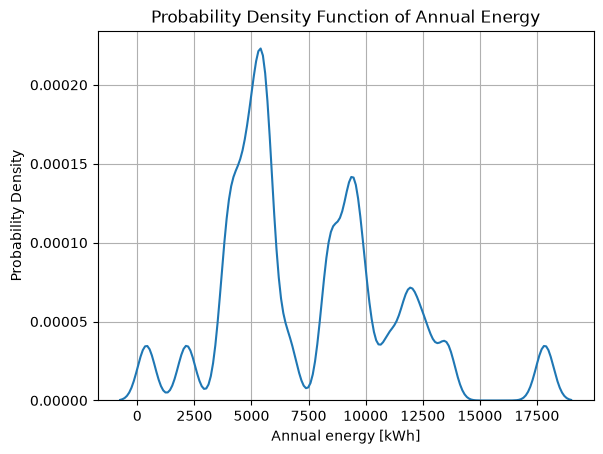

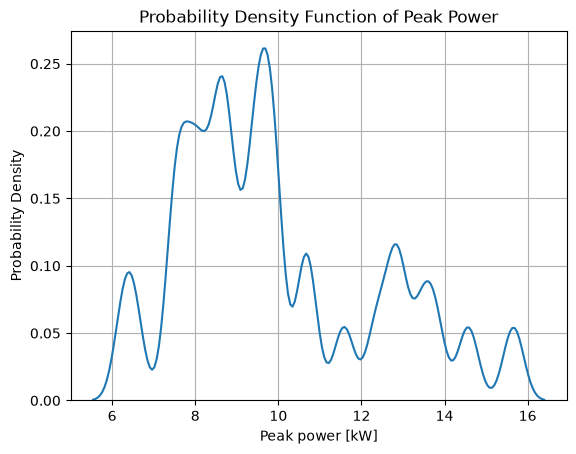

In [55]:
vis.load_prob_density_plot(power_dict_train)
vis.load_prob_density_plot(power_dict_test)